In [31]:
import pandas as pd

prices = pd.read_csv('../data/rawdata/aapl_stock_prices.csv')
indicators = pd.read_csv('../data/rawdata/aapl_technical_indicators.csv')
indicators = indicators.drop(columns=['Unnamed: 0'], errors='ignore')
prices['Date'] = pd.to_datetime(prices['Date'])
indicators['Date'] = pd.to_datetime(indicators['Date'])
prices = prices.sort_values('Date')
indicators = indicators.sort_values('Date')
df = pd.merge(prices, indicators, on='Date', how='inner')
#print(prices.isnull().sum())
#print(indicators.isnull().sum())
#print(df.shape)
#print(df.head())
#print(prices.head())
#print(indicators.head())
#df.duplicated().sum()
#df.dtypes
df = df.rename(columns={
    'High_x': 'high_price',
    'High_y': 'high_indicator',
    'Low_x': 'low_price',
    'Low_y': 'low_indicator',
    'Close_x': 'close_price',
    'Close_y': 'close_indicator',
    'Open_x': 'open_price',
    'Open_y': 'open_indicator',
    'Volume_x': 'volume_price',
    'Volume_y': 'volume_indicator'
})

df = df.drop(columns=[
    'open_price', 'high_price', 'low_price', 'close_price', 'volume_price'
])
print(df.shape)
print(df.head())
df.isnull().sum()
df = df.sort_values('Date')
df.to_csv('../data/processed/cleaned_stock_data.csv', index=False)


(9, 7)
        Date  open_indicator  high_indicator  low_indicator  close_indicator  \
0 2004-12-31        4.635000        4.642857       4.573571         4.600000   
1 2005-01-03        4.627143        4.650714       4.471428         4.520714   
2 2005-01-04        4.556428        4.676429       4.497857         4.567143   
3 2005-01-05        4.604286        4.660714       4.575000         4.607143   
4 2005-01-06        4.619286        4.636428       4.523571         4.610714   

   Adj Close  volume_indicator  
0   3.114000        69647200.0  
1   3.060327       172998000.0  
2   3.091757       274202600.0  
3   3.118836       170108400.0  
4   3.121253       176388800.0  


OSError: Cannot save file into a non-existent directory: '../data/processed'

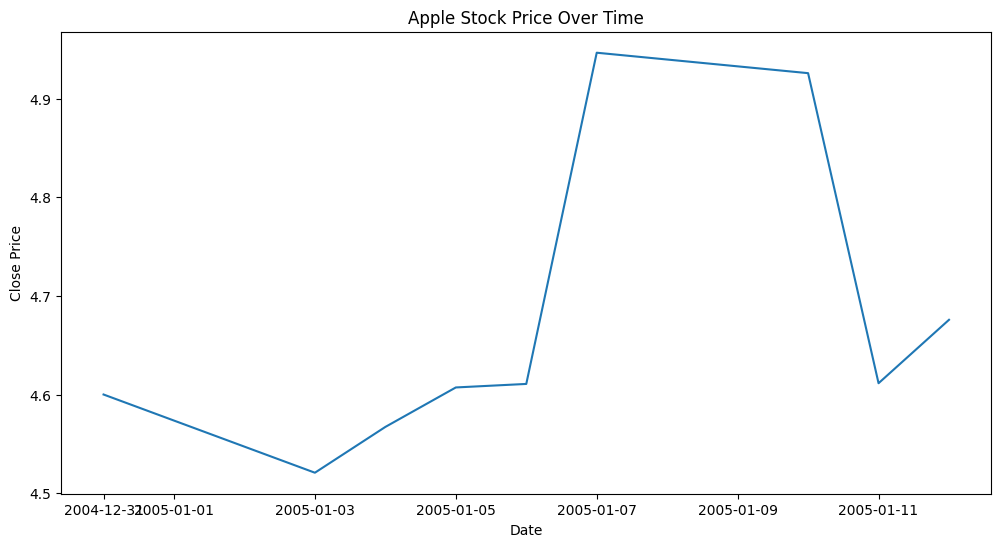

In [29]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['close_indicator'])
plt.title("Apple Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()